SciPy is not available or broken. Welch t-test will be skipped.
UV sheet shape: (95, 21)
Litmus sheet shape: (30, 10)

Cleaned coated suture LAB data:
     pH  Replicate  Absorbance     L*    a*     b*
3   5.5        1.0       0.326  59.85 -7.96 -22.24
6   5.5        2.0       0.291  62.69 -8.54 -21.65
9   5.5        3.0       0.415  46.05  2.30 -34.50
12  5.5        4.0       0.505  46.24 -4.11 -25.42
15  5.5        5.0       0.413  53.42 -6.90 -23.19

Cleaned litmus LAB data:
    pH  Replicate      L*      a*     b*
0  5.5        1.0  49.873  15.041  6.125
1  5.5        2.0  48.707  13.808  4.427
2  5.5        3.0  50.202  11.818  3.888
3  5.5        4.0  49.272  10.828  2.671
4  5.5        5.0  46.015  10.375  0.281

SOP 2 - Descriptive Statistics


,n,absorbance_mean,absorbance_sd,L_mean,L_sd,a_mean,a_sd,b_mean,b_sd,Descriptive_Color_Trend
pH,,,,,,,,,,
5.5,5,0.390,0.084,53.650,7.630,-5.042,4.443,-25.400,5.285,"moderately dark, greenish, bluish"
6.5,5,0.417,0.029,53.570,2.631,-11.984,2.412,-22.666,1.551,"moderately dark, greenish, bluish"
7.0,5,0.515,0.053,47.626,2.789,5.542,4.563,-22.284,0.832,"moderately dark, reddish, bluish"
7.5,5,0.419,0.036,53.614,2.930,-8.086,3.645,-22.342,4.799,"moderately dark, greenish, bluish"
8.5,5,0.532,0.037,55.934,2.363,-13.220,1.977,-9.018,2.558,"light, greenish, bluish"


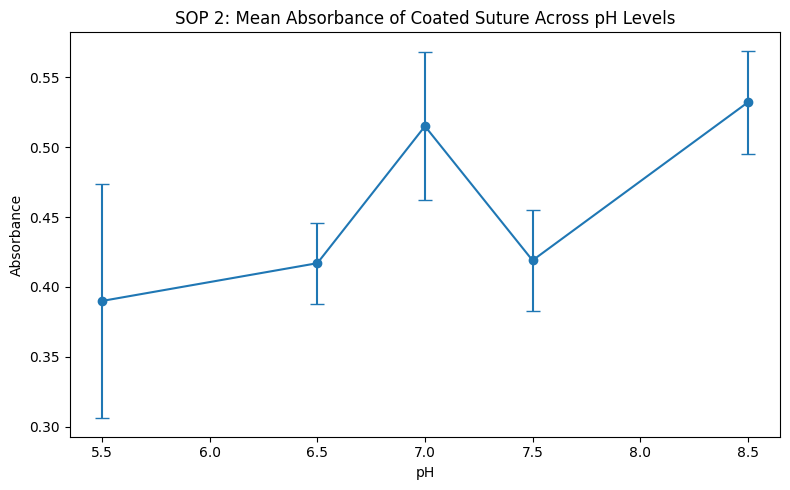

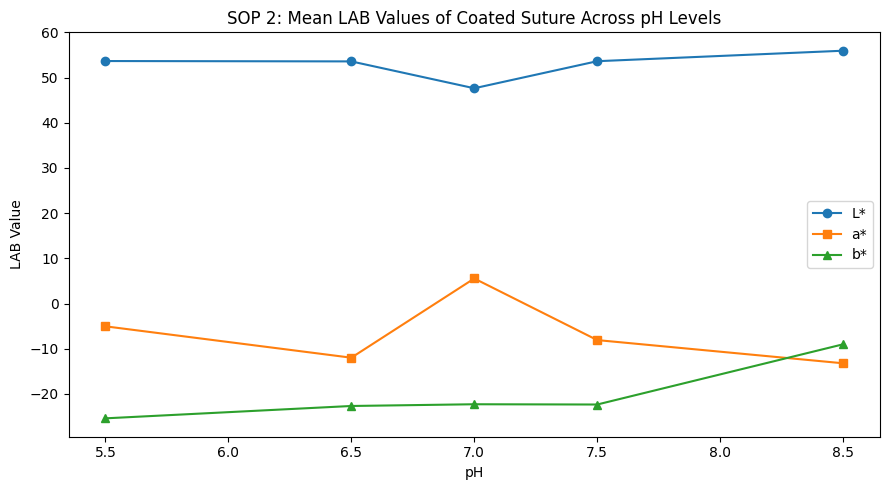

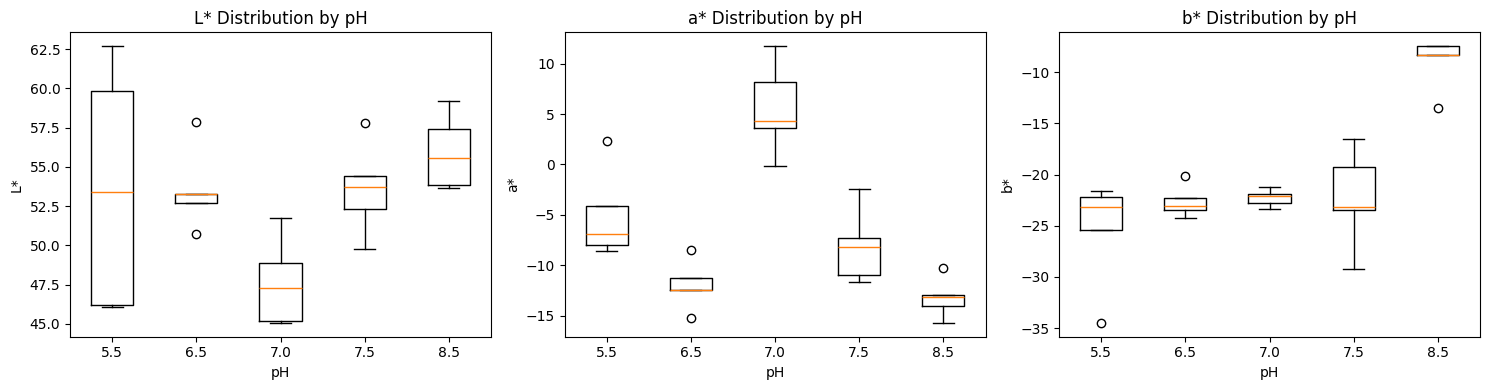

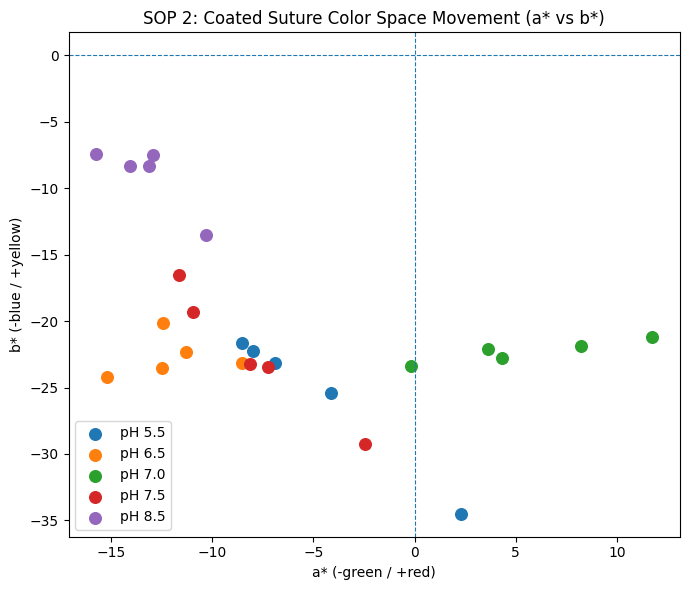


Combined comparison data:
        Material   pH  Replicate  DeltaE_from_pH7
0  Coated Suture  5.5        1.0        18.213515
1  Coated Suture  5.5        2.0        20.630773
2  Coated Suture  5.5        3.0        12.736758
3  Coated Suture  5.5        4.0        10.242880
4  Coated Suture  5.5        5.0        13.754804

SOP 4 - Descriptive Statistics


n  mean_deltaE  sd_deltaE  min_deltaE  max_deltaE
Material      pH                                                    
Coated Suture 5.5  5       15.116      4.221      10.243      20.631
              6.5  5       18.669      2.791      14.425      21.438
              7.0  5        4.247      2.597       1.373       7.129
              7.5  5       15.701      3.705      10.817      19.580
              8.5  5       24.522      3.260      19.135      27.703
Litmus Paper  5.5  5        5.761      2.106       3.144       8.713
              6.5  5        6.321      1.936       3.142       8.028
              7.0  5        3.083      1.246       1.838       4.956
              7.5  5        7.955      2.379       5.060      10.703
              8.5  5       11.121      0.960      10.023      12.161


Welch t-test skipped because SciPy is unavailable.


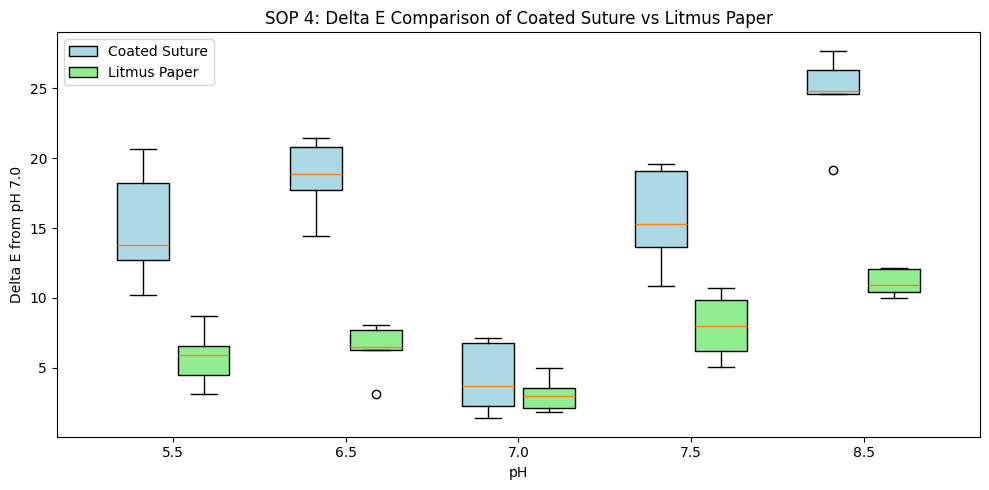

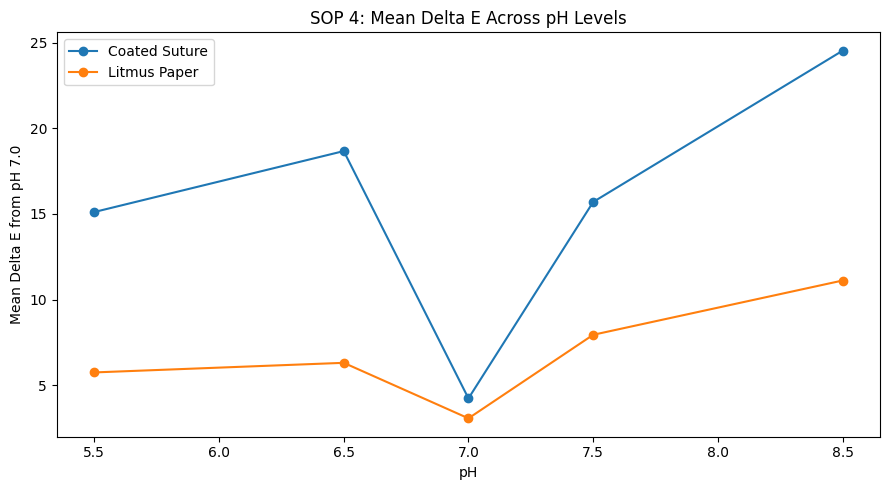

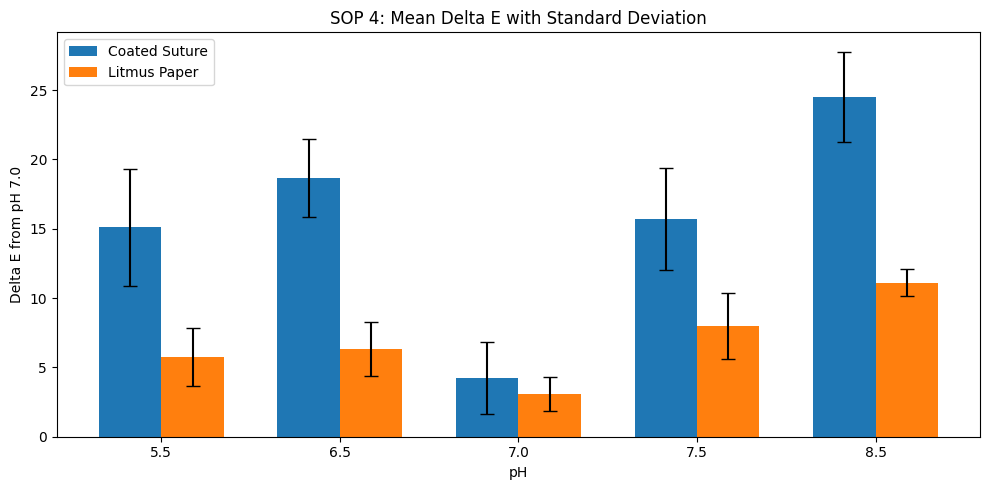


Done. Outputs saved in: outputs


In [3]:
# =========================
# JUPYTER NOTEBOOK SETUP
# =========================
%matplotlib inline

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional scipy import
try:
    from scipy.stats import ttest_ind
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    print("SciPy is not available or broken. Welch t-test will be skipped.")

# -------------------------
# USER SETTINGS
# -------------------------
file_path = "UV-Vis Spectro Results.xlsx"   # change if needed
output_folder = "outputs"
os.makedirs(output_folder, exist_ok=True)

plt.style.use("default")


# =========================
# HELPER FUNCTIONS
# =========================
def clean_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def delta_e_cie76(df, ref_lab):
    return np.sqrt(
        (df["L*"] - ref_lab["L*"])**2 +
        (df["a*"] - ref_lab["a*"])**2 +
        (df["b*"] - ref_lab["b*"])**2
    )


def interpret_lab(L, a, b):
    if L >= 70:
        lightness = "very light"
    elif L >= 55:
        lightness = "light"
    elif L >= 40:
        lightness = "moderately dark"
    else:
        lightness = "dark"

    if a > 3:
        rg = "reddish"
    elif a < -3:
        rg = "greenish"
    else:
        rg = "near-neutral red/green"

    if b > 3:
        by = "yellowish"
    elif b < -3:
        by = "bluish"
    else:
        by = "near-neutral blue/yellow"

    return f"{lightness}, {rg}, {by}"


def grouped_boxplot(ax, data_dict, title, ylabel):
    labels = list(data_dict.keys())
    values = [data_dict[k].dropna().values for k in labels]
    ax.boxplot(values, tick_labels=labels)
    ax.set_title(title)
    ax.set_xlabel("pH")
    ax.set_ylabel(ylabel)


# =========================
# LOAD DATA
# =========================
uv_raw = clean_columns(pd.read_excel(file_path, sheet_name="UV Vis-Spectro Anthocyanin", engine="openpyxl"))
litmus_raw = clean_columns(pd.read_excel(file_path, sheet_name="ImageJ Litmus LAB and XYZ", engine="openpyxl"))

print("UV sheet shape:", uv_raw.shape)
print("Litmus sheet shape:", litmus_raw.shape)


# =========================
# CLEAN UV-VIS COATED SUTURE DATA
# SOP 2 SOURCE
# =========================
uv_raw["pH"] = pd.to_numeric(uv_raw["pH"], errors="coerce").ffill()

uv_reps = uv_raw[uv_raw["Replicate"].notna()].copy()
uv_reps["Replicate"] = pd.to_numeric(uv_reps["Replicate"], errors="coerce")
uv_reps["pH"] = pd.to_numeric(uv_reps["pH"], errors="coerce")

coated_lab = uv_reps[
    (uv_reps["Replicate"] > 0) &
    uv_reps[["L*", "a*", "b*"]].notna().all(axis=1)
].copy()

coated_lab = coated_lab[["pH", "Replicate", "Absorbance", "L*", "a*", "b*"]].sort_values(["pH", "Replicate"])

print("\nCleaned coated suture LAB data:")
print(coated_lab.head())


# =========================
# CLEAN LITMUS DATA
# SOP 4 SOURCE
# =========================
mean_rows = litmus_raw["pH"].astype(str).str.strip().eq("Mean")
litmus_raw["block"] = mean_rows.shift(fill_value=False).cumsum()

litmus_raw["pH_num"] = pd.to_numeric(litmus_raw["pH"], errors="coerce")
litmus_raw["pH_clean"] = litmus_raw.groupby("block")["pH_num"].transform(
    lambda s: s.dropna().iloc[0] if not s.dropna().empty else np.nan
)

litmus_lab = litmus_raw[litmus_raw["Replicate"].notna()].copy()
litmus_lab["Replicate"] = pd.to_numeric(litmus_lab["Replicate"], errors="coerce")
litmus_lab["pH"] = pd.to_numeric(litmus_lab["pH_clean"], errors="coerce")

litmus_lab = litmus_lab[["pH", "Replicate", "L*", "a*", "b*"]].sort_values(["pH", "Replicate"])

print("\nCleaned litmus LAB data:")
print(litmus_lab.head())


# =========================
# SOP 2 - DESCRIPTIVE STATS
# =========================
sop2_stats = coated_lab.groupby("pH").agg(
    n=("Replicate", "count"),
    absorbance_mean=("Absorbance", "mean"),
    absorbance_sd=("Absorbance", "std"),
    L_mean=("L*", "mean"),
    L_sd=("L*", "std"),
    a_mean=("a*", "mean"),
    a_sd=("a*", "std"),
    b_mean=("b*", "mean"),
    b_sd=("b*", "std")
).round(3)

sop2_stats["Descriptive_Color_Trend"] = sop2_stats.apply(
    lambda row: interpret_lab(row["L_mean"], row["a_mean"], row["b_mean"]),
    axis=1
)

print("\nSOP 2 - Descriptive Statistics")
display(sop2_stats)


# =========================
# SOP 2 - VISUALIZATIONS
# =========================

# 1) Mean absorbance by pH with SD
plt.figure(figsize=(8, 5))
plt.errorbar(
    sop2_stats.index.astype(float),
    sop2_stats["absorbance_mean"],
    yerr=sop2_stats["absorbance_sd"],
    marker="o",
    capsize=5
)
plt.title("SOP 2: Mean Absorbance of Coated Suture Across pH Levels")
plt.xlabel("pH")
plt.ylabel("Absorbance")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop2_absorbance_vs_ph.png"), dpi=300)
plt.show()

# 2) Mean LAB values across pH
plt.figure(figsize=(9, 5))
plt.plot(sop2_stats.index.astype(float), sop2_stats["L_mean"], marker="o", label="L*")
plt.plot(sop2_stats.index.astype(float), sop2_stats["a_mean"], marker="s", label="a*")
plt.plot(sop2_stats.index.astype(float), sop2_stats["b_mean"], marker="^", label="b*")
plt.title("SOP 2: Mean LAB Values of Coated Suture Across pH Levels")
plt.xlabel("pH")
plt.ylabel("LAB Value")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop2_lab_vs_ph.png"), dpi=300)
plt.show()

# 3) Boxplots for L*, a*, b*
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

grouped_boxplot(
    axes[0],
    {str(k): v["L*"] for k, v in coated_lab.groupby("pH")},
    "L* Distribution by pH",
    "L*"
)
grouped_boxplot(
    axes[1],
    {str(k): v["a*"] for k, v in coated_lab.groupby("pH")},
    "a* Distribution by pH",
    "a*"
)
grouped_boxplot(
    axes[2],
    {str(k): v["b*"] for k, v in coated_lab.groupby("pH")},
    "b* Distribution by pH",
    "b*"
)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop2_lab_boxplots.png"), dpi=300)
plt.show()

# 4) a* vs b* scatter
plt.figure(figsize=(7, 6))
for ph, grp in coated_lab.groupby("pH"):
    plt.scatter(grp["a*"], grp["b*"], s=70, label=f"pH {ph}")

plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axvline(0, linestyle="--", linewidth=0.8)
plt.title("SOP 2: Coated Suture Color Space Movement (a* vs b*)")
plt.xlabel("a* (-green / +red)")
plt.ylabel("b* (-blue / +yellow)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop2_ab_scatter.png"), dpi=300)
plt.show()


# =========================
# SOP 4 - DELTA E COMPARISON
# =========================
coated_ref_lab = coated_lab[coated_lab["pH"] == 7.0][["L*", "a*", "b*"]].mean()
litmus_ref_lab = litmus_lab[litmus_lab["pH"] == 7.0][["L*", "a*", "b*"]].mean()

coated_compare = coated_lab.copy()
coated_compare["Material"] = "Coated Suture"
coated_compare["DeltaE_from_pH7"] = delta_e_cie76(coated_compare, coated_ref_lab)

litmus_compare = litmus_lab.copy()
litmus_compare["Material"] = "Litmus Paper"
litmus_compare["DeltaE_from_pH7"] = delta_e_cie76(litmus_compare, litmus_ref_lab)

comparison_df = pd.concat([
    coated_compare[["Material", "pH", "Replicate", "DeltaE_from_pH7"]],
    litmus_compare[["Material", "pH", "Replicate", "DeltaE_from_pH7"]]
], ignore_index=True)

print("\nCombined comparison data:")
print(comparison_df.head())


# =========================
# SOP 4 - DESCRIPTIVE STATS
# =========================
sop4_stats = comparison_df.groupby(["Material", "pH"]).agg(
    n=("Replicate", "count"),
    mean_deltaE=("DeltaE_from_pH7", "mean"),
    sd_deltaE=("DeltaE_from_pH7", "std"),
    min_deltaE=("DeltaE_from_pH7", "min"),
    max_deltaE=("DeltaE_from_pH7", "max")
).round(3)

print("\nSOP 4 - Descriptive Statistics")
display(sop4_stats)


# =========================
# SOP 4 - OPTIONAL WELCH T-TEST
# =========================
if SCIPY_AVAILABLE:
    ttest_results = []

    for ph in sorted(comparison_df["pH"].dropna().unique()):
        coated_vals = comparison_df[
            (comparison_df["Material"] == "Coated Suture") &
            (comparison_df["pH"] == ph)
        ]["DeltaE_from_pH7"].dropna()

        litmus_vals = comparison_df[
            (comparison_df["Material"] == "Litmus Paper") &
            (comparison_df["pH"] == ph)
        ]["DeltaE_from_pH7"].dropna()

        if len(coated_vals) > 1 and len(litmus_vals) > 1:
            t_stat, p_value = ttest_ind(coated_vals, litmus_vals, equal_var=False)
        else:
            t_stat, p_value = np.nan, np.nan

        ttest_results.append({
            "pH": ph,
            "Coated_Mean_DeltaE": coated_vals.mean(),
            "Litmus_Mean_DeltaE": litmus_vals.mean(),
            "t_stat": t_stat,
            "p_value": p_value,
            "Significant_at_0_05": "Yes" if pd.notna(p_value) and p_value < 0.05 else "No"
        })

    ttest_results = pd.DataFrame(ttest_results).round(4)

    print("\nSOP 4 - Welch t-test Results by pH")
    display(ttest_results)
else:
    ttest_results = pd.DataFrame()
    print("\nWelch t-test skipped because SciPy is unavailable.")


# =========================
# SOP 4 - VISUALIZATIONS
# =========================

# 1) Boxplot comparison
fig, ax = plt.subplots(figsize=(10, 5))

ph_levels = sorted(comparison_df["pH"].dropna().unique())
positions = np.arange(len(ph_levels))
width = 0.35

coated_box_data = [
    comparison_df[(comparison_df["Material"] == "Coated Suture") & (comparison_df["pH"] == ph)]["DeltaE_from_pH7"].dropna()
    for ph in ph_levels
]
litmus_box_data = [
    comparison_df[(comparison_df["Material"] == "Litmus Paper") & (comparison_df["pH"] == ph)]["DeltaE_from_pH7"].dropna()
    for ph in ph_levels
]

bp1 = ax.boxplot(coated_box_data, positions=positions - width/2, widths=0.3, patch_artist=True)
bp2 = ax.boxplot(litmus_box_data, positions=positions + width/2, widths=0.3, patch_artist=True)

for patch in bp1["boxes"]:
    patch.set_facecolor("lightblue")
for patch in bp2["boxes"]:
    patch.set_facecolor("lightgreen")

ax.set_xticks(positions)
ax.set_xticklabels([str(ph) for ph in ph_levels])
ax.set_title("SOP 4: Delta E Comparison of Coated Suture vs Litmus Paper")
ax.set_xlabel("pH")
ax.set_ylabel("Delta E from pH 7.0")
ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Coated Suture", "Litmus Paper"])
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop4_deltaE_boxplot.png"), dpi=300)
plt.show()

# 2) Mean Delta E line plot
mean_deltae_plot = comparison_df.groupby(["Material", "pH"])["DeltaE_from_pH7"].mean().reset_index()

plt.figure(figsize=(9, 5))
for material in mean_deltae_plot["Material"].unique():
    temp = mean_deltae_plot[mean_deltae_plot["Material"] == material]
    plt.plot(temp["pH"], temp["DeltaE_from_pH7"], marker="o", label=material)

plt.title("SOP 4: Mean Delta E Across pH Levels")
plt.xlabel("pH")
plt.ylabel("Mean Delta E from pH 7.0")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop4_deltaE_lineplot.png"), dpi=300)
plt.show()

# 3) Mean ± SD bar chart
coated_summary = comparison_df[comparison_df["Material"] == "Coated Suture"].groupby("pH")["DeltaE_from_pH7"].agg(["mean", "std"])
litmus_summary = comparison_df[comparison_df["Material"] == "Litmus Paper"].groupby("pH")["DeltaE_from_pH7"].agg(["mean", "std"])

x = np.arange(len(ph_levels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(
    x - width/2,
    coated_summary.loc[ph_levels, "mean"],
    width,
    yerr=coated_summary.loc[ph_levels, "std"],
    capsize=5,
    label="Coated Suture"
)
plt.bar(
    x + width/2,
    litmus_summary.loc[ph_levels, "mean"],
    width,
    yerr=litmus_summary.loc[ph_levels, "std"],
    capsize=5,
    label="Litmus Paper"
)

plt.xticks(x, [str(ph) for ph in ph_levels])
plt.title("SOP 4: Mean Delta E with Standard Deviation")
plt.xlabel("pH")
plt.ylabel("Delta E from pH 7.0")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop4_deltaE_barplot_sd.png"), dpi=300)
plt.show()


# =========================
# EXPORT RESULTS
# =========================
sop2_stats.to_csv(os.path.join(output_folder, "sop2_descriptive_stats.csv"))
sop4_stats.to_csv(os.path.join(output_folder, "sop4_deltaE_descriptive_stats.csv"))

if not ttest_results.empty:
    ttest_results.to_csv(os.path.join(output_folder, "sop4_ttest_results.csv"), index=False)

with pd.ExcelWriter(os.path.join(output_folder, "sop2_sop4_results.xlsx"), engine="openpyxl") as writer:
    sop2_stats.to_excel(writer, sheet_name="SOP2_Stats")
    sop4_stats.to_excel(writer, sheet_name="SOP4_Stats")
    if not ttest_results.empty:
        ttest_results.to_excel(writer, sheet_name="SOP4_TTests", index=False)

print(f"\nDone. Outputs saved in: {output_folder}")

Cleaned SOP 3 dataset:


,pH,Trial,Seconds,Mean,Response_ms,Condition
0,5.5,1,5.28,4.566,5280.0,Non-infection
1,5.5,2,5.27,NaN,5270.0,Non-infection
2,5.5,3,3.28,NaN,3280.0,Non-infection
3,5.5,4,4.40,NaN,4400.0,Non-infection
4,5.5,5,4.60,NaN,4600.0,Non-infection
5,6.5,1,5.60,6.120,5600.0,Non-infection
6,6.5,2,7.10,NaN,7100.0,Non-infection
7,6.5,3,4.85,NaN,4850.0,Non-infection
8,6.5,4,7.00,NaN,7000.0,Non-infection
9,6.5,5,6.05,NaN,6050.0,Non-infection



SOP 3 - Descriptive Statistics by pH


,,n,mean_seconds,sd_seconds,mean_ms,sd_ms,min_ms,max_ms
pH,Condition,,,,,,,
5.5,Non-infection,5,4.566,0.820,4566.0,819.744,3280.0,5280.0
6.5,Non-infection,5,6.120,0.952,6120.0,951.709,4850.0,7100.0
7.0,Non-infection,5,4.280,0.451,4280.0,451.276,3520.0,4650.0
7.5,Infection-indicative,5,3.458,0.283,3458.0,282.790,3170.0,3810.0
8.5,Infection-indicative,5,1.502,0.228,1502.0,228.298,1150.0,1710.0



SOP 3 - Descriptive Statistics by Condition


,n,mean_seconds,sd_seconds,mean_ms,sd_ms,min_ms,max_ms
Condition,,,,,,,
Infection-indicative,10,2.480,1.059,2480.000,1058.993,1150.0,3810.0
Non-infection,15,4.989,1.100,4988.667,1099.655,3280.0,7100.0



SOP 3 - Mean Difference Summary


,Comparison,Mean_Difference_ms,Percent_Change_vs_NonInfection
0,Infection-indicative - Non-infection,-2508.667,-50.287



SOP 3 - Statistical Test Results


,Test,Statistic,p_value,Interpretation
0,Welch's t-test,-5.7139,0.000014,Significant difference
1,Mann-Whitney U,5.5000,0.000129,Significant difference


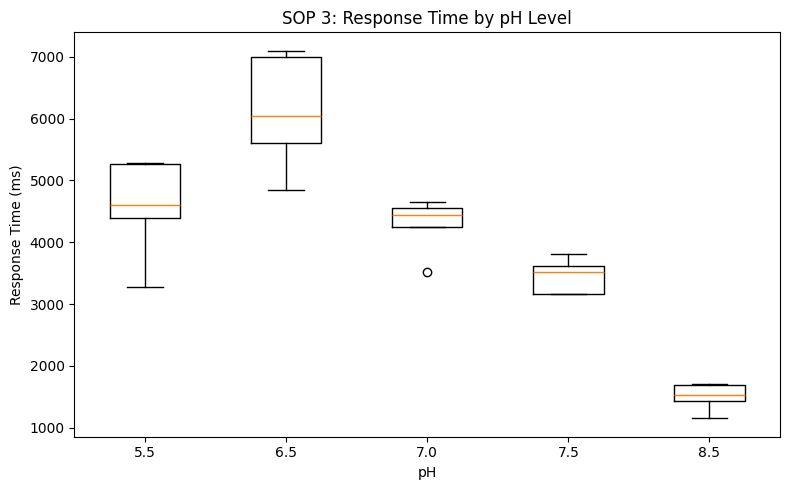

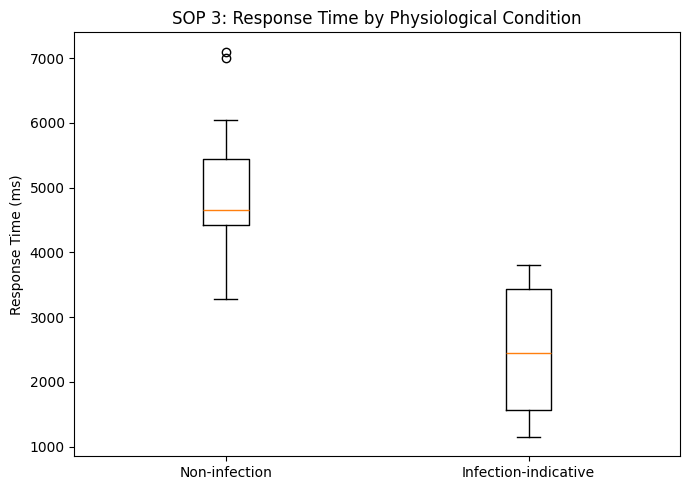

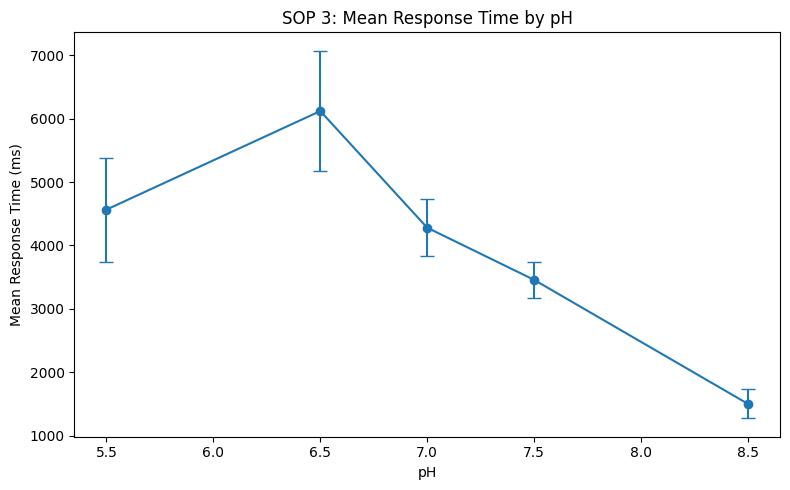

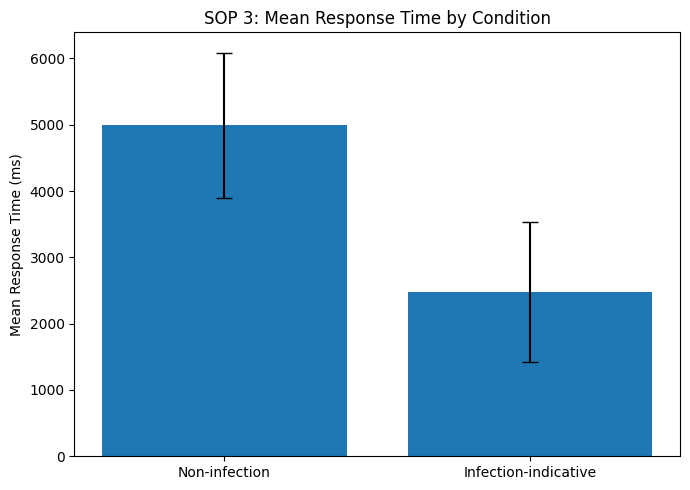


SOP 3 - 95% Confidence Interval for Mean Difference


,Comparison,Mean_Difference_ms,CI_95_Lower,CI_95_Upper
0,Infection-indicative - Non-infection,-2508.667,-3424.623,-1592.71



Done. SOP 3 outputs saved in: outputs_sop3


In [2]:
# =========================
# SOP 3: RESPONSE TIME ANALYSIS
# Jupyter Notebook Version
# =========================

%matplotlib inline

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional statistical tests
try:
    from scipy.stats import ttest_ind, mannwhitneyu
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    print("SciPy is not available or is broken. Statistical tests will be skipped.")

# -------------------------
# USER SETTINGS
# -------------------------
file_path = "UV-Vis Spectro Results.xlsx"   # change if needed
sheet_name = "Time Response"
output_folder = "outputs_sop3"
os.makedirs(output_folder, exist_ok=True)

plt.style.use("default")


# =========================
# LOAD AND CLEAN DATA
# =========================
df = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")

# Clean column names
df.columns = [str(col).strip() for col in df.columns]

# Forward fill pH because only the first row of each block has pH written
df["pH"] = pd.to_numeric(df["pH"], errors="coerce").ffill()

# Make sure numeric columns are numeric
df["Trial"] = pd.to_numeric(df["Trial"], errors="coerce")
df["Seconds"] = pd.to_numeric(df["Seconds"], errors="coerce")

# Remove rows with missing trial or seconds
df = df[df["Trial"].notna() & df["Seconds"].notna()].copy()

# Convert response time to milliseconds
df["Response_ms"] = df["Seconds"] * 1000

# Assign physiological condition groups
df["Condition"] = np.where(df["pH"] >= 7.5, "Infection-indicative", "Non-infection")

# Sort for neat display
df = df.sort_values(["pH", "Trial"]).reset_index(drop=True)

print("Cleaned SOP 3 dataset:")
display(df)


# =========================
# DESCRIPTIVE STATISTICS BY pH
# =========================
stats_by_ph = df.groupby(["pH", "Condition"]).agg(
    n=("Trial", "count"),
    mean_seconds=("Seconds", "mean"),
    sd_seconds=("Seconds", "std"),
    mean_ms=("Response_ms", "mean"),
    sd_ms=("Response_ms", "std"),
    min_ms=("Response_ms", "min"),
    max_ms=("Response_ms", "max")
).round(3)

print("\nSOP 3 - Descriptive Statistics by pH")
display(stats_by_ph)


# =========================
# DESCRIPTIVE STATISTICS BY CONDITION
# =========================
stats_by_condition = df.groupby("Condition").agg(
    n=("Trial", "count"),
    mean_seconds=("Seconds", "mean"),
    sd_seconds=("Seconds", "std"),
    mean_ms=("Response_ms", "mean"),
    sd_ms=("Response_ms", "std"),
    min_ms=("Response_ms", "min"),
    max_ms=("Response_ms", "max")
).round(3)

print("\nSOP 3 - Descriptive Statistics by Condition")
display(stats_by_condition)


# =========================
# EFFECT SIZE / DIFFERENCE
# =========================
group_means = df.groupby("Condition")["Response_ms"].mean()

if "Non-infection" in group_means.index and "Infection-indicative" in group_means.index:
    mean_diff = group_means["Infection-indicative"] - group_means["Non-infection"]
    percent_change = (mean_diff / group_means["Non-infection"]) * 100

    difference_summary = pd.DataFrame({
        "Comparison": ["Infection-indicative - Non-infection"],
        "Mean_Difference_ms": [round(mean_diff, 3)],
        "Percent_Change_vs_NonInfection": [round(percent_change, 3)]
    })

    print("\nSOP 3 - Mean Difference Summary")
    display(difference_summary)
else:
    difference_summary = pd.DataFrame()


# =========================
# OPTIONAL STATISTICAL TESTS
# =========================
test_results = []

if SCIPY_AVAILABLE:
    non_inf = df[df["Condition"] == "Non-infection"]["Response_ms"].dropna()
    inf = df[df["Condition"] == "Infection-indicative"]["Response_ms"].dropna()

    if len(non_inf) > 1 and len(inf) > 1:
        # Welch's t-test
        t_stat, t_p = ttest_ind(inf, non_inf, equal_var=False)

        # Mann-Whitney U test
        u_stat, u_p = mannwhitneyu(inf, non_inf, alternative="two-sided")

        test_results = pd.DataFrame({
            "Test": ["Welch's t-test", "Mann-Whitney U"],
            "Statistic": [round(t_stat, 4), round(u_stat, 4)],
            "p_value": [round(t_p, 6), round(u_p, 6)],
            "Interpretation": [
                "Significant difference" if t_p < 0.05 else "Not significant",
                "Significant difference" if u_p < 0.05 else "Not significant"
            ]
        })

        print("\nSOP 3 - Statistical Test Results")
        display(test_results)
    else:
        print("\nNot enough values for statistical testing.")
        test_results = pd.DataFrame()
else:
    print("\nSciPy tests skipped.")
    test_results = pd.DataFrame()


# =========================
# VISUALIZATIONS
# =========================

# 1. Boxplot by pH
plt.figure(figsize=(8, 5))
ph_levels = sorted(df["pH"].dropna().unique())
box_data = [df[df["pH"] == ph]["Response_ms"].dropna() for ph in ph_levels]

plt.boxplot(box_data, tick_labels=[str(ph) for ph in ph_levels])
plt.title("SOP 3: Response Time by pH Level")
plt.xlabel("pH")
plt.ylabel("Response Time (ms)")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop3_boxplot_by_ph.png"), dpi=300)
plt.show()


# 2. Boxplot by condition
plt.figure(figsize=(7, 5))
condition_order = ["Non-infection", "Infection-indicative"]
box_data_cond = [df[df["Condition"] == cond]["Response_ms"].dropna() for cond in condition_order]

plt.boxplot(box_data_cond, tick_labels=condition_order)
plt.title("SOP 3: Response Time by Physiological Condition")
plt.ylabel("Response Time (ms)")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop3_boxplot_by_condition.png"), dpi=300)
plt.show()


# 3. Mean response time by pH with SD
summary_ph = df.groupby("pH")["Response_ms"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(8, 5))
plt.errorbar(
    summary_ph["pH"],
    summary_ph["mean"],
    yerr=summary_ph["std"],
    marker="o",
    capsize=5
)
plt.title("SOP 3: Mean Response Time by pH")
plt.xlabel("pH")
plt.ylabel("Mean Response Time (ms)")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop3_mean_response_by_ph.png"), dpi=300)
plt.show()


# 4. Mean response time by condition
summary_cond = df.groupby("Condition")["Response_ms"].agg(["mean", "std"]).reindex(condition_order)

plt.figure(figsize=(7, 5))
x = np.arange(len(summary_cond))
plt.bar(
    x,
    summary_cond["mean"],
    yerr=summary_cond["std"],
    capsize=6
)
plt.xticks(x, summary_cond.index)
plt.title("SOP 3: Mean Response Time by Condition")
plt.ylabel("Mean Response Time (ms)")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop3_mean_response_by_condition.png"), dpi=300)
plt.show()


# =========================
# OPTIONAL 95% CI FOR MEAN DIFFERENCE
# =========================
ci_table = pd.DataFrame()

if SCIPY_AVAILABLE and len(non_inf) > 1 and len(inf) > 1:
    # Welch-style approximate CI for difference in means
    mean_inf = inf.mean()
    mean_non = non_inf.mean()
    var_inf = inf.var(ddof=1)
    var_non = non_inf.var(ddof=1)
    n_inf = len(inf)
    n_non = len(non_inf)

    diff = mean_inf - mean_non
    se = np.sqrt((var_inf / n_inf) + (var_non / n_non))

    # approximate critical value for 95% CI
    # if scipy works, use t distribution
    try:
        from scipy.stats import t
        df_welch = ((var_inf / n_inf + var_non / n_non) ** 2) / (
            ((var_inf / n_inf) ** 2) / (n_inf - 1) +
            ((var_non / n_non) ** 2) / (n_non - 1)
        )
        t_crit = t.ppf(0.975, df_welch)
    except Exception:
        t_crit = 1.96

    ci_low = diff - t_crit * se
    ci_high = diff + t_crit * se

    ci_table = pd.DataFrame({
        "Comparison": ["Infection-indicative - Non-infection"],
        "Mean_Difference_ms": [round(diff, 3)],
        "CI_95_Lower": [round(ci_low, 3)],
        "CI_95_Upper": [round(ci_high, 3)]
    })

    print("\nSOP 3 - 95% Confidence Interval for Mean Difference")
    display(ci_table)


# =========================
# EXPORT RESULTS
# =========================
df.to_csv(os.path.join(output_folder, "sop3_cleaned_data.csv"), index=False)
stats_by_ph.to_csv(os.path.join(output_folder, "sop3_stats_by_ph.csv"))
stats_by_condition.to_csv(os.path.join(output_folder, "sop3_stats_by_condition.csv"))

if not difference_summary.empty:
    difference_summary.to_csv(os.path.join(output_folder, "sop3_difference_summary.csv"), index=False)

if isinstance(test_results, pd.DataFrame) and not test_results.empty:
    test_results.to_csv(os.path.join(output_folder, "sop3_test_results.csv"), index=False)

if not ci_table.empty:
    ci_table.to_csv(os.path.join(output_folder, "sop3_ci_table.csv"), index=False)

with pd.ExcelWriter(os.path.join(output_folder, "sop3_results.xlsx"), engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    stats_by_ph.to_excel(writer, sheet_name="Stats_by_pH")
    stats_by_condition.to_excel(writer, sheet_name="Stats_by_Condition")
    if not difference_summary.empty:
        difference_summary.to_excel(writer, sheet_name="Difference_Summary", index=False)
    if isinstance(test_results, pd.DataFrame) and not test_results.empty:
        test_results.to_excel(writer, sheet_name="Statistical_Tests", index=False)
    if not ci_table.empty:
        ci_table.to_excel(writer, sheet_name="CI_Mean_Difference", index=False)

print(f"\nDone. SOP 3 outputs saved in: {output_folder}")

Cleaned SOP 1 dataset:


,Material,Trial,Diameter_mm,Area_mm2,Peak_Load_N,Mean N,UTS_MPa,Mean MPa
0,Coated Abaca,1,1.2,1.130973,600,584.0,530.516477,345.118729
1,Coated Abaca,2,1.5,1.767146,580,NaN,328.212860,NaN
2,Coated Abaca,3,1.6,2.010619,530,NaN,263.600374,NaN
3,Coated Abaca,4,1.5,1.767146,560,NaN,316.895176,NaN
4,Coated Abaca,5,1.7,2.269801,650,NaN,286.368756,NaN
5,Uncoated Abaca,1,2.0,3.141593,830,956.0,264.197205,372.403801
6,Uncoated Abaca,2,1.9,2.835287,960,NaN,338.590017,NaN
7,Uncoated Abaca,3,1.7,2.269801,1040,NaN,458.190009,NaN
8,Uncoated Abaca,4,2.3,4.154756,930,NaN,223.839844,NaN
9,Uncoated Abaca,5,1.5,1.767146,1020,NaN,577.201927,NaN



SOP 1 - Descriptive Statistics by Material


,n,mean_peak_load_N,sd_peak_load_N,min_peak_load_N,max_peak_load_N,mean_UTS_MPa,sd_UTS_MPa,min_UTS_MPa,max_UTS_MPa,mean_diameter_mm,sd_diameter_mm,mean_area_mm2,sd_area_mm2
Material,,,,,,,,,,,,,
Coated Abaca,5,584.0,45.056,530,650,345.119,106.714,263.60,530.516,1.50,0.187,1.789,0.423
Uncoated Abaca,5,956.0,83.247,830,1040,372.404,145.108,223.84,577.202,1.88,0.303,2.834,0.908
Commercial Catgut,5,270.0,15.811,250,290,343.775,20.132,318.31,369.239,1.00,0.000,0.785,0.000


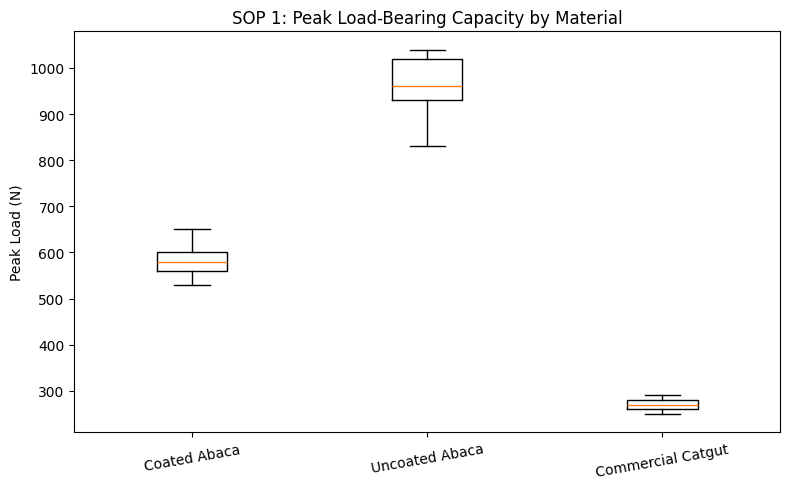

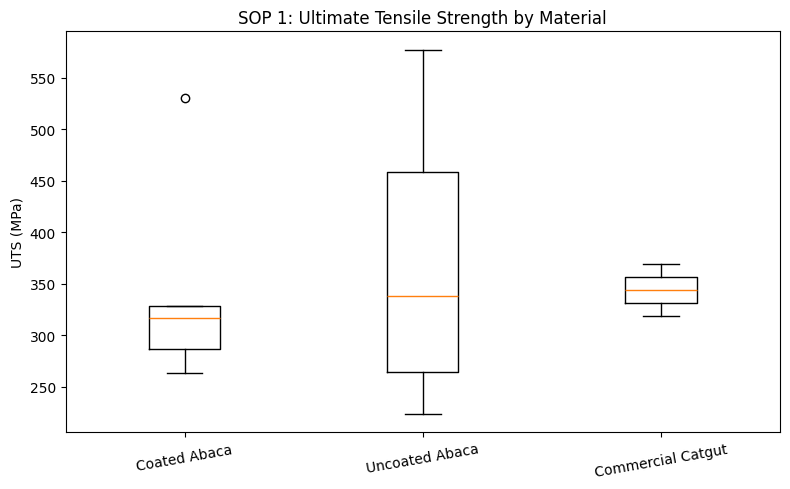

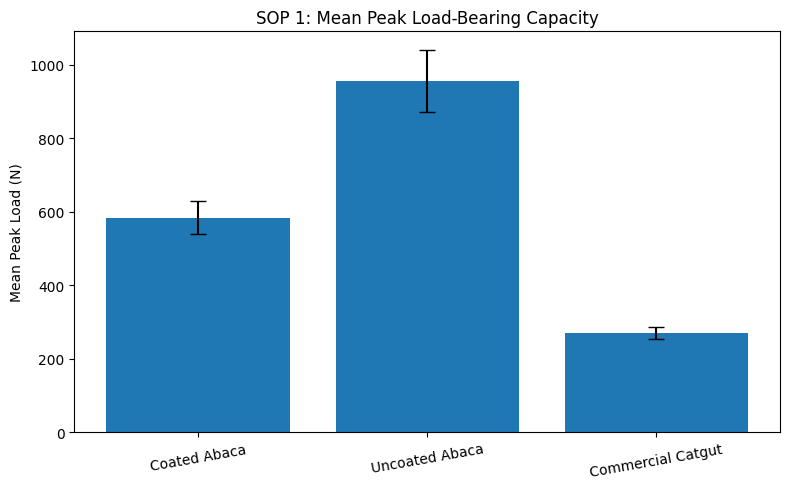

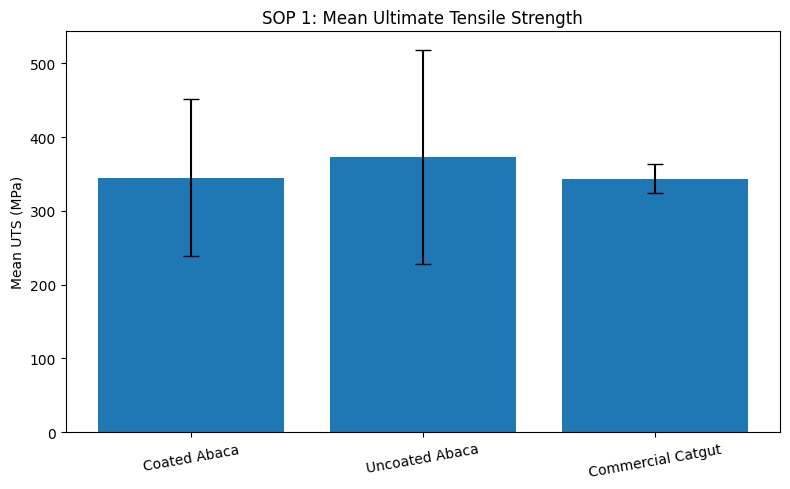

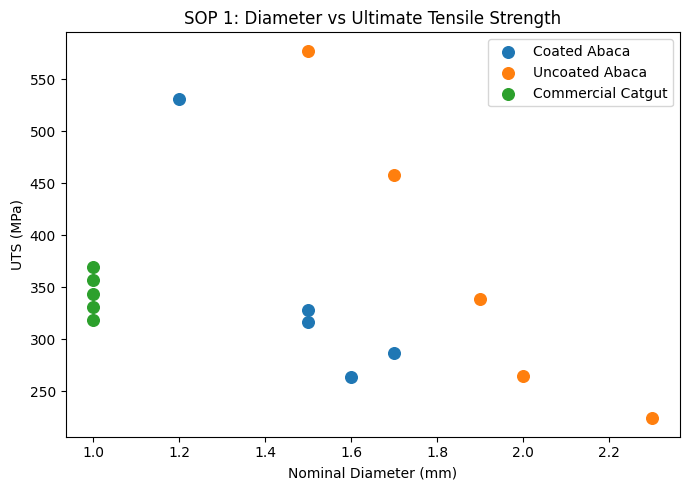


SOP 1 - One-way ANOVA Results


,Metric,F_statistic,p_value,Interpretation
0,Peak Load (N),192.0673,0.000000,Significant difference
1,Ultimate Tensile Strength (MPa),0.1192,0.888691,Not significant



SOP 1 - Kruskal-Wallis Results


,Metric,H_statistic,p_value,Interpretation
0,Peak Load (N),12.50,0.001930,Significant difference
1,Ultimate Tensile Strength (MPa),1.14,0.565525,Not significant



SOP 1 - Pairwise Welch t-test Results


,Metric,Comparison,t_statistic,p_value,Interpretation
0,Peak Load (N),Coated Abaca vs Uncoated Abaca,-8.7877,0.000104,Significant difference
1,Ultimate Tensile Strength (MPa),Coated Abaca vs Uncoated Abaca,-0.3387,0.744295,Not significant
2,Peak Load (N),Coated Abaca vs Commercial Catgut,14.7044,0.000027,Significant difference
3,Ultimate Tensile Strength (MPa),Coated Abaca vs Commercial Catgut,0.0277,0.979163,Not significant
4,Peak Load (N),Uncoated Abaca vs Commercial Catgut,18.1028,0.000033,Significant difference
5,Ultimate Tensile Strength (MPa),Uncoated Abaca vs Commercial Catgut,0.4370,0.683886,Not significant



SOP 1 - Material Ranking


,mean_peak_load_N,mean_UTS_MPa,Peak_Load_Rank,UTS_Rank
Material,,,,
Coated Abaca,584.0,345.119,2,2
Uncoated Abaca,956.0,372.404,1,1
Commercial Catgut,270.0,343.775,3,3



Done. SOP 1 outputs saved in: outputs_sop1


In [4]:
# =========================
# SOP 1: MECHANICAL INTEGRITY ANALYSIS
# Jupyter Notebook Version
# =========================

%matplotlib inline

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional statistical testing
try:
    from scipy.stats import f_oneway, kruskal, ttest_ind
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    print("SciPy is not available or is broken. Inferential statistical tests will be skipped.")

# -------------------------
# USER SETTINGS
# -------------------------
file_path = "UV-Vis Spectro Results.xlsx"   # change if needed
sheet_name = "Tensile Strength"
output_folder = "outputs_sop1"
os.makedirs(output_folder, exist_ok=True)

plt.style.use("default")


# =========================
# LOAD DATA
# =========================
df = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")

# Clean column names
df.columns = [str(col).strip() for col in df.columns]

# Forward fill material type because only first row in each block has label
df["Type"] = df["Type"].ffill()

# Rename for cleaner presentation
df = df.rename(columns={
    "Type": "Material",
    "N": "Peak_Load_N",
    "MPa": "UTS_MPa",
    "Nominal Diameter (mm)": "Diameter_mm",
    "Cross-Sectional Area (mm²)": "Area_mm2"
})

# Optional relabeling for thesis wording
df["Material"] = df["Material"].replace({
    "Uncoated": "Uncoated Abaca",
    "Coated": "Coated Abaca",
    "Chromic Catgut": "Commercial Catgut"
})

# Ensure numeric columns are numeric
numeric_cols = ["Trial", "Diameter_mm", "Area_mm2", "Peak_Load_N", "UTS_MPa"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep only valid rows
df = df[df["Trial"].notna() & df["Peak_Load_N"].notna() & df["UTS_MPa"].notna()].copy()

# Optional recompute UTS if missing
if df["UTS_MPa"].isna().any():
    df["UTS_MPa"] = df["Peak_Load_N"] / df["Area_mm2"]

# Sort for clean display
material_order = ["Coated Abaca", "Uncoated Abaca", "Commercial Catgut"]
df["Material"] = pd.Categorical(df["Material"], categories=material_order, ordered=True)
df = df.sort_values(["Material", "Trial"]).reset_index(drop=True)

print("Cleaned SOP 1 dataset:")
display(df)


# =========================
# DESCRIPTIVE STATISTICS
# =========================
desc_stats = df.groupby("Material").agg(
    n=("Trial", "count"),
    mean_peak_load_N=("Peak_Load_N", "mean"),
    sd_peak_load_N=("Peak_Load_N", "std"),
    min_peak_load_N=("Peak_Load_N", "min"),
    max_peak_load_N=("Peak_Load_N", "max"),
    mean_UTS_MPa=("UTS_MPa", "mean"),
    sd_UTS_MPa=("UTS_MPa", "std"),
    min_UTS_MPa=("UTS_MPa", "min"),
    max_UTS_MPa=("UTS_MPa", "max"),
    mean_diameter_mm=("Diameter_mm", "mean"),
    sd_diameter_mm=("Diameter_mm", "std"),
    mean_area_mm2=("Area_mm2", "mean"),
    sd_area_mm2=("Area_mm2", "std")
).round(3)

print("\nSOP 1 - Descriptive Statistics by Material")
display(desc_stats)


# =========================
# VISUALIZATIONS
# =========================

# 1. Boxplot: Peak Load-Bearing Capacity
plt.figure(figsize=(8, 5))
box_data_peak = [df[df["Material"] == mat]["Peak_Load_N"].dropna() for mat in material_order]
plt.boxplot(box_data_peak, tick_labels=material_order)
plt.title("SOP 1: Peak Load-Bearing Capacity by Material")
plt.ylabel("Peak Load (N)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop1_boxplot_peak_load.png"), dpi=300)
plt.show()

# 2. Boxplot: Ultimate Tensile Strength
plt.figure(figsize=(8, 5))
box_data_uts = [df[df["Material"] == mat]["UTS_MPa"].dropna() for mat in material_order]
plt.boxplot(box_data_uts, tick_labels=material_order)
plt.title("SOP 1: Ultimate Tensile Strength by Material")
plt.ylabel("UTS (MPa)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop1_boxplot_uts.png"), dpi=300)
plt.show()

# 3. Mean ± SD bar chart for Peak Load
peak_summary = df.groupby("Material")["Peak_Load_N"].agg(["mean", "std"]).reindex(material_order)

x = np.arange(len(material_order))
plt.figure(figsize=(8, 5))
plt.bar(
    x,
    peak_summary["mean"],
    yerr=peak_summary["std"],
    capsize=6
)
plt.xticks(x, material_order, rotation=10)
plt.title("SOP 1: Mean Peak Load-Bearing Capacity")
plt.ylabel("Mean Peak Load (N)")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop1_bar_peak_load.png"), dpi=300)
plt.show()

# 4. Mean ± SD bar chart for UTS
uts_summary = df.groupby("Material")["UTS_MPa"].agg(["mean", "std"]).reindex(material_order)

x = np.arange(len(material_order))
plt.figure(figsize=(8, 5))
plt.bar(
    x,
    uts_summary["mean"],
    yerr=uts_summary["std"],
    capsize=6
)
plt.xticks(x, material_order, rotation=10)
plt.title("SOP 1: Mean Ultimate Tensile Strength")
plt.ylabel("Mean UTS (MPa)")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop1_bar_uts.png"), dpi=300)
plt.show()

# 5. Scatter plot: Diameter vs UTS
plt.figure(figsize=(7, 5))
for mat in material_order:
    temp = df[df["Material"] == mat]
    plt.scatter(temp["Diameter_mm"], temp["UTS_MPa"], label=mat, s=70)

plt.title("SOP 1: Diameter vs Ultimate Tensile Strength")
plt.xlabel("Nominal Diameter (mm)")
plt.ylabel("UTS (MPa)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "sop1_scatter_diameter_vs_uts.png"), dpi=300)
plt.show()


# =========================
# INFERENTIAL STATISTICS
# =========================
anova_results = pd.DataFrame()
kruskal_results = pd.DataFrame()
pairwise_results = pd.DataFrame()

if SCIPY_AVAILABLE:
    # Group arrays
    coated_peak = df[df["Material"] == "Coated Abaca"]["Peak_Load_N"].dropna()
    uncoated_peak = df[df["Material"] == "Uncoated Abaca"]["Peak_Load_N"].dropna()
    catgut_peak = df[df["Material"] == "Commercial Catgut"]["Peak_Load_N"].dropna()

    coated_uts = df[df["Material"] == "Coated Abaca"]["UTS_MPa"].dropna()
    uncoated_uts = df[df["Material"] == "Uncoated Abaca"]["UTS_MPa"].dropna()
    catgut_uts = df[df["Material"] == "Commercial Catgut"]["UTS_MPa"].dropna()

    # -------------------------
    # One-way ANOVA
    # -------------------------
    f_peak, p_peak = f_oneway(coated_peak, uncoated_peak, catgut_peak)
    f_uts, p_uts = f_oneway(coated_uts, uncoated_uts, catgut_uts)

    anova_results = pd.DataFrame({
        "Metric": ["Peak Load (N)", "Ultimate Tensile Strength (MPa)"],
        "F_statistic": [round(f_peak, 4), round(f_uts, 4)],
        "p_value": [round(p_peak, 6), round(p_uts, 6)],
        "Interpretation": [
            "Significant difference" if p_peak < 0.05 else "Not significant",
            "Significant difference" if p_uts < 0.05 else "Not significant"
        ]
    })

    print("\nSOP 1 - One-way ANOVA Results")
    display(anova_results)

    # -------------------------
    # Kruskal-Wallis
    # -------------------------
    h_peak, kp_peak = kruskal(coated_peak, uncoated_peak, catgut_peak)
    h_uts, kp_uts = kruskal(coated_uts, uncoated_uts, catgut_uts)

    kruskal_results = pd.DataFrame({
        "Metric": ["Peak Load (N)", "Ultimate Tensile Strength (MPa)"],
        "H_statistic": [round(h_peak, 4), round(h_uts, 4)],
        "p_value": [round(kp_peak, 6), round(kp_uts, 6)],
        "Interpretation": [
            "Significant difference" if kp_peak < 0.05 else "Not significant",
            "Significant difference" if kp_uts < 0.05 else "Not significant"
        ]
    })

    print("\nSOP 1 - Kruskal-Wallis Results")
    display(kruskal_results)

    # -------------------------
    # Pairwise Welch t-tests
    # -------------------------
    pairwise_list = []

    comparisons = [
        ("Coated Abaca", "Uncoated Abaca"),
        ("Coated Abaca", "Commercial Catgut"),
        ("Uncoated Abaca", "Commercial Catgut")
    ]

    for m1, m2 in comparisons:
        vals1_peak = df[df["Material"] == m1]["Peak_Load_N"].dropna()
        vals2_peak = df[df["Material"] == m2]["Peak_Load_N"].dropna()

        vals1_uts = df[df["Material"] == m1]["UTS_MPa"].dropna()
        vals2_uts = df[df["Material"] == m2]["UTS_MPa"].dropna()

        t_peak, p_peak_pair = ttest_ind(vals1_peak, vals2_peak, equal_var=False)
        t_uts, p_uts_pair = ttest_ind(vals1_uts, vals2_uts, equal_var=False)

        pairwise_list.append({
            "Metric": "Peak Load (N)",
            "Comparison": f"{m1} vs {m2}",
            "t_statistic": round(t_peak, 4),
            "p_value": round(p_peak_pair, 6),
            "Interpretation": "Significant difference" if p_peak_pair < 0.05 else "Not significant"
        })

        pairwise_list.append({
            "Metric": "Ultimate Tensile Strength (MPa)",
            "Comparison": f"{m1} vs {m2}",
            "t_statistic": round(t_uts, 4),
            "p_value": round(p_uts_pair, 6),
            "Interpretation": "Significant difference" if p_uts_pair < 0.05 else "Not significant"
        })

    pairwise_results = pd.DataFrame(pairwise_list)

    print("\nSOP 1 - Pairwise Welch t-test Results")
    display(pairwise_results)

else:
    print("\nSciPy not available. Only descriptive statistics and plots were generated.")


# =========================
# SIMPLE RANKING TABLE
# =========================
ranking_table = desc_stats[["mean_peak_load_N", "mean_UTS_MPa"]].copy()
ranking_table["Peak_Load_Rank"] = ranking_table["mean_peak_load_N"].rank(ascending=False, method="min").astype(int)
ranking_table["UTS_Rank"] = ranking_table["mean_UTS_MPa"].rank(ascending=False, method="min").astype(int)

print("\nSOP 1 - Material Ranking")
display(ranking_table)


# =========================
# EXPORT RESULTS
# =========================
df.to_csv(os.path.join(output_folder, "sop1_cleaned_data.csv"), index=False)
desc_stats.to_csv(os.path.join(output_folder, "sop1_descriptive_stats.csv"))
ranking_table.to_csv(os.path.join(output_folder, "sop1_ranking_table.csv"))

if not anova_results.empty:
    anova_results.to_csv(os.path.join(output_folder, "sop1_anova_results.csv"), index=False)

if not kruskal_results.empty:
    kruskal_results.to_csv(os.path.join(output_folder, "sop1_kruskal_results.csv"), index=False)

if not pairwise_results.empty:
    pairwise_results.to_csv(os.path.join(output_folder, "sop1_pairwise_results.csv"), index=False)

with pd.ExcelWriter(os.path.join(output_folder, "sop1_results.xlsx"), engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    desc_stats.to_excel(writer, sheet_name="Descriptive_Stats")
    ranking_table.to_excel(writer, sheet_name="Ranking")
    if not anova_results.empty:
        anova_results.to_excel(writer, sheet_name="ANOVA", index=False)
    if not kruskal_results.empty:
        kruskal_results.to_excel(writer, sheet_name="Kruskal", index=False)
    if not pairwise_results.empty:
        pairwise_results.to_excel(writer, sheet_name="Pairwise_TTests", index=False)

print(f"\nDone. SOP 1 outputs saved in: {output_folder}")